# RADAE — Residual Attentive Denoising Auto-Encoder
## Belgacem et al. 2025 — Implementation on Amazon Product Reviews

### Pipeline
| Section | Description |
|---|---|
| 0 | Imports & Setup |
| 1 | Load & Preprocess Amazon Product Reviews |
| 2 | Inject Synthetic Noise (for evaluation) |
| 3 | Temporal Feature Engineering |
| 4 | RADAE Model Architecture |
| 5 | Training Pipeline |
| 6 | Evaluation: RMSE · MAE · P@K · R@K · NDCG@K |
| 7 | Comparison vs No-Defence Baseline |
| 8 | Noise Resilience Analysis |
| 9 | Final Results Summary |


# Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Deep learning
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model, optimizers, losses
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print(f'  TensorFlow version: {tf.__version__}')
    USE_TF = True
except ImportError:
    print('  TensorFlow not found — install with: pip install tensorflow')
    print('  Falling back to numpy-based simplified RADAE')
    USE_TF = False

warnings.filterwarnings('ignore')
np.random.seed(42)
if USE_TF:
    tf.random.set_seed(42)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('='*65)
print('RADAE — Belgacem et al. 2025')
print('Amazon Product Reviews Dataset')
print('='*65)

  TensorFlow version: 2.21.0
RADAE — Belgacem et al. 2025
Amazon Product Reviews Dataset


# Load & Preprocess Amazon Product Reviews

In [3]:
print('[1] Loading Amazon Product Reviews...')

df_raw = pd.read_csv('Amazon_Product_Reviews.csv', low_memory=False)

# Column mapping 
df = df_raw[[
    'reviews.username', 'asins', 'reviews.rating',
    'reviews.date', 'reviews.numHelpful',
    'reviews.doRecommend', 'reviews.text'
]].copy()

df.rename(columns={
    'reviews.username'   : 'customer_id',
    'asins'              : 'product_id',
    'reviews.rating'     : 'star_rating',
    'reviews.date'       : 'review_date',
    'reviews.numHelpful' : 'helpful_votes',
    'reviews.doRecommend': 'do_recommend',
    'reviews.text'       : 'review_body',
}, inplace=True)

# Clean
df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')
df.dropna(subset=['product_id','star_rating'], inplace=True)
df = df[df['star_rating'].between(1,5)].copy()
df['star_rating']   = df['star_rating'].astype(int)
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0)
df['review_date']   = pd.to_datetime(df['review_date'], errors='coerce')
df['review_length'] = df['review_body'].fillna('').apply(len)

# Fix missing usernames 
mask = df['customer_id'].isna()
df.loc[mask, 'customer_id'] = [f'anon_{i}' for i in df.index[mask]]

# Integer ID encoding (RADAE requires integer indices) 
user_ids = {u: i for i, u in enumerate(df['customer_id'].unique())}
item_ids = {p: i for i, p in enumerate(df['product_id'].unique())}
df['user_idx'] = df['customer_id'].map(user_ids)
df['item_idx'] = df['product_id'].map(item_ids)

n_users = len(user_ids)
n_items = len(item_ids)

# Timestamp normalisation (0.0 to 1.0) 
# RADAE paper: timestamps embedded as continuous values
# representing temporal position in the interaction history
ts_min = df['review_date'].min()
ts_max = df['review_date'].max()
ts_range = (ts_max - ts_min).total_seconds()
df['timestamp_norm'] = df['review_date'].apply(
    lambda x: (x - ts_min).total_seconds() / ts_range
    if pd.notna(x) else 0.5
)

# Rating normalisation (1-5 → 0-1) for neural model 
df['rating_norm'] = (df['star_rating'] - 1) / 4.0

print(f'  Dataset shape    : {df.shape}')
print(f'  Unique users     : {n_users}')
print(f'  Unique items     : {n_items}')
print(f'  Date range       : {ts_min.date()} → {ts_max.date()}')
print(f'  Rating dist      :\n{df["star_rating"].value_counts().sort_index()}')
print(f'\n  Sample prepared rows:')
print(df[['user_idx','item_idx','star_rating','rating_norm',
          'timestamp_norm','review_length']].head())

[1] Loading Amazon Product Reviews...
  Dataset shape    : (1177, 12)
  Unique users     : 836
  Unique items     : 54
  Date range       : 2012-09-12 → 2017-07-31
  Rating dist      :
star_rating
1     42
2     34
3    124
4    236
5    741
Name: count, dtype: int64

  Sample prepared rows:
   user_idx  item_idx  star_rating  rating_norm  timestamp_norm  review_length
0         0         0            5         1.00        0.594504           1064
1         1         0            5         1.00        0.607964           1424
2         2         0            4         0.75        0.583847            182
3         3         0            5         1.00        0.974762           1671
4         4         0            5         1.00        0.801458           1916


# Inject Synthetic Noise

Two noise types injected:
- **Gaussian noise** — adds random perturbation (natural noise simulation)
- **Shilling attack** — pushes target items to 5★ (malicious noise simulation)

In [4]:
print('[2] Injecting synthetic noise for evaluation...')

df_clean  = df.copy()
df_noisy  = df.copy()

# ── Gaussian noise (natural noise simulation) ─────────────────────────
# Adds random ±noise to ratings, clipped to valid range
GAUSSIAN_STD = 0.5   # noise level in rating units
noise_vals   = np.random.normal(0, GAUSSIAN_STD, len(df_noisy))
df_noisy['rating_corrupted'] = np.clip(
    df_noisy['star_rating'] + noise_vals, 1, 5
)
df_noisy['rating_corrupted_norm'] = (df_noisy['rating_corrupted'] - 1) / 4.0

# ── Shilling attack injection (malicious noise simulation) ────────────
# Following Lam & Riedl 2004 — Random Attack:
# Fake users push target items to 5★
ATTACK_SIZE    = 0.05   # 5% contamination
N_TARGET_ITEMS = 3
item_counts    = df.groupby('item_idx').size().sort_values(ascending=False)
target_items   = item_counts.head(N_TARGET_ITEMS).index.tolist()
n_fake         = max(20, int(len(df) * ATTACK_SIZE))

fake_rows = []
for i in range(n_fake):
    fake_user  = n_users + i   # fake user IDs beyond real range
    target_item= np.random.choice(target_items)
    fake_rows.append({
        'user_idx'              : fake_user,
        'item_idx'              : target_item,
        'star_rating'           : 5,
        'rating_norm'           : 1.0,
        'rating_corrupted'      : 5.0,
        'rating_corrupted_norm' : 1.0,
        'timestamp_norm'        : np.random.uniform(0.8, 1.0),
        'is_attack'             : 1,
        'review_length'         : 15,
    })

df_attacks = pd.DataFrame(fake_rows)

# Clean data: use original ratings as corrupted (no added noise)
df_noisy['is_attack'] = 0
df_noisy['rating_corrupted'].fillna(df_noisy['star_rating'], inplace=True)

# Combined noisy training dataset
df_combined = pd.concat([df_noisy, df_attacks],
                         ignore_index=True, sort=False)
df_combined['rating_corrupted_norm'] = (
    df_combined['rating_corrupted_norm'].fillna(
    df_combined['rating_norm'])
)
df_combined['timestamp_norm'] = df_combined['timestamp_norm'].fillna(0.5)

# Extend user/item count to include fake users
n_users_ext = n_users + n_fake

print(f'  Clean dataset rows    : {len(df_clean):,}')
print(f'  Gaussian noise added  : std = {GAUSSIAN_STD}')
print(f'  Shilling attacks      : {n_fake:,} fake profiles')
print(f'  Target items attacked : {target_items}')
print(f'  Combined training     : {len(df_combined):,} rows')
print(f'  Attack proportion     : {n_fake/len(df_combined)*100:.1f}%')


[2] Injecting synthetic noise for evaluation...
  Clean dataset rows    : 1,177
  Gaussian noise added  : std = 0.5
  Shilling attacks      : 58 fake profiles
  Target items attacked : [47, 51, 3]
  Combined training     : 1,235 rows
  Attack proportion     : 4.7%


# Temportal Feature Engineering

[3] Temporal Feature Engineering...
  Temporal weight range : 0.135 – 1.000
  Temporal buckets dist :
temporal_bucket
0.0      5
1.0     10
2.0    348
3.0     78
4.0    794
Name: count, dtype: int64


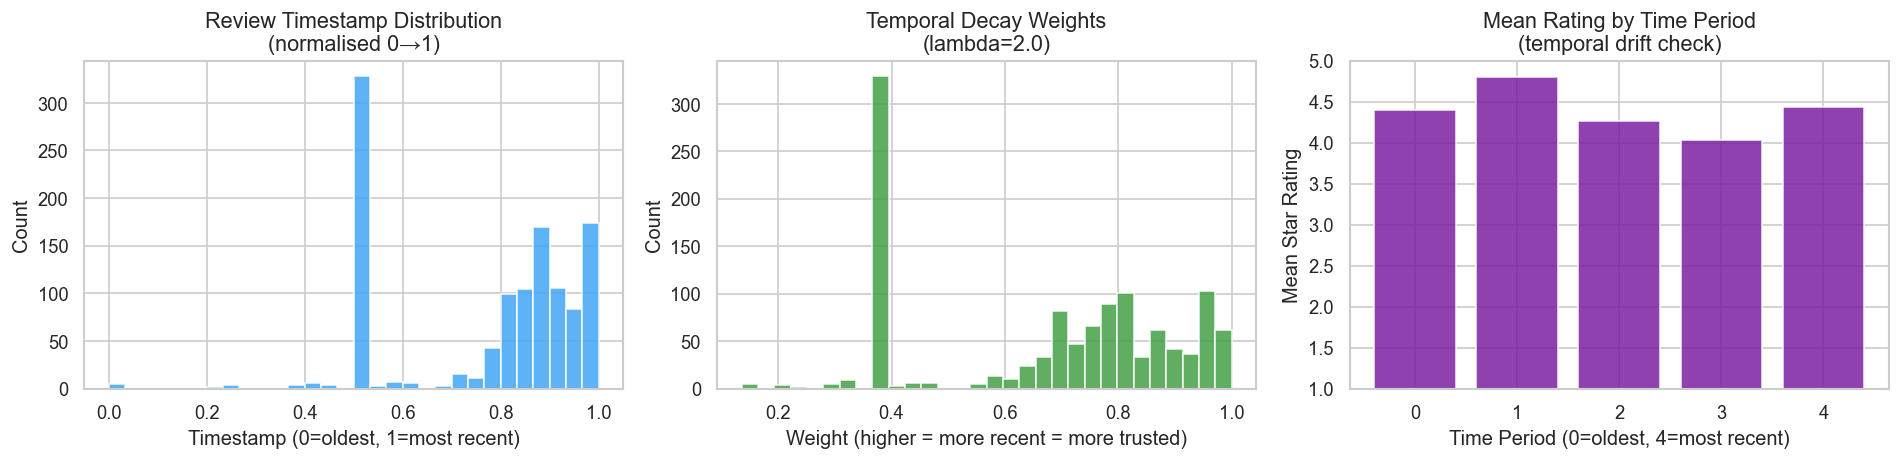

  Saved: fig_radae_temporal_features.png


In [5]:
print('[3] Temporal Feature Engineering...')

# Temporal decay weight
# RADAE paper: temporal adaptation means recent ratings matter more
# Exponential decay: w(t) = exp(-lambda * (1 - t_norm))
# where t_norm=1 is most recent, t_norm=0 is oldest
DECAY_LAMBDA = 2.0   # controls how fast old ratings lose weight

df_combined['temporal_weight'] = np.exp(
    -DECAY_LAMBDA * (1 - df_combined['timestamp_norm'].fillna(0.5))
).astype(np.float32)

# Also apply to clean dataset
df_clean['temporal_weight'] = np.exp(
    -DECAY_LAMBDA * (1 - df_clean['timestamp_norm'])
).astype(np.float32)

# Temporal buckets (5 equal time periods) 
df_combined['temporal_bucket'] = pd.cut(
    df_combined['timestamp_norm'],
    bins=5, labels=[0,1,2,3,4]
).astype(float).fillna(2)

df_clean['temporal_bucket'] = pd.cut(
    df_clean['timestamp_norm'],
    bins=5, labels=[0,1,2,3,4]
).astype(float).fillna(2)

print(f'  Temporal weight range : '
      f'{df_combined["temporal_weight"].min():.3f} – '
      f'{df_combined["temporal_weight"].max():.3f}')
print(f'  Temporal buckets dist :\n'
      f'{df_combined["temporal_bucket"].value_counts().sort_index()}')

# Visualise temporal distribution 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_clean['timestamp_norm'], bins=30,
             color='#42a5f5', edgecolor='white', alpha=0.85)
axes[0].set_title('Review Timestamp Distribution\n(normalised 0→1)')
axes[0].set_xlabel('Timestamp (0=oldest, 1=most recent)')
axes[0].set_ylabel('Count')

axes[1].hist(df_clean['temporal_weight'], bins=30,
             color='#43a047', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Temporal Decay Weights\n(lambda={DECAY_LAMBDA})')
axes[1].set_xlabel('Weight (higher = more recent = more trusted)')
axes[1].set_ylabel('Count')

# Mean rating by time bucket
bucket_means = df_clean.groupby('temporal_bucket')['star_rating'].mean()
axes[2].bar(bucket_means.index, bucket_means.values,
            color='#7b1fa2', edgecolor='white', alpha=0.85)
axes[2].set_title('Mean Rating by Time Period\n(temporal drift check)')
axes[2].set_xlabel('Time Period (0=oldest, 4=most recent)')
axes[2].set_ylabel('Mean Star Rating')
axes[2].set_ylim(1, 5)

plt.tight_layout()
plt.savefig('fig_radae_temporal_features.png', bbox_inches='tight')
plt.show()
print('  Saved: fig_radae_temporal_features.png')


# RADAE Model Architecture

In [6]:
print('[4] Building RADAE Model Architecture...')

# Hyperparameters (following Belgacem 2025 paper conventions)
EMBED_DIM   = 32    # embedding dimension for users and items
LATENT_DIM  = 64    # bottleneck latent representation size
CONV_FILTERS= 64    # Conv1D number of filters
CONV_KERNEL = 3     # Conv1D kernel size
N_HEADS     = 4     # multi-head attention heads
KEY_DIM     = 16    # attention key dimension
DROPOUT     = 0.2   # dropout rate
LEARNING_RATE = 0.001

if USE_TF:

    def build_radae(n_users_in, n_items_in,
                    embed_dim=EMBED_DIM, latent_dim=LATENT_DIM,
                    conv_filters=CONV_FILTERS, conv_kernel=CONV_KERNEL,
                    n_heads=N_HEADS, key_dim=KEY_DIM,
                    dropout=DROPOUT):
        """
        RADAE — Residual Attentive Denoising Auto-Encoder
        Belgacem et al. 2025, Journal of Intelligent & Fuzzy Systems
        doi:10.1177/18758967251409840

        Inputs:
          user_input   : (batch,) integer user index
          item_input   : (batch,) integer item index
          ts_input     : (batch,) normalised timestamp [0,1]
          rating_input : (batch,) normalised corrupted rating [0,1]
        Output:
          denoised normalised rating prediction [0,1]
        """

        # Inputs
        user_input   = layers.Input(shape=(1,), name='user_input',
                                     dtype='int32')
        item_input   = layers.Input(shape=(1,), name='item_input',
                                     dtype='int32')
        ts_input     = layers.Input(shape=(1,), name='ts_input',
                                     dtype='float32')
        rating_input = layers.Input(shape=(1,), name='rating_input',
                                     dtype='float32')

        # Embeddings
        # User embedding: latent user preference space
        user_emb = layers.Embedding(
            input_dim=n_users_in + 1,
            output_dim=embed_dim,
            name='user_embedding'
        )(user_input)
        user_emb = layers.Flatten()(user_emb)   # (batch, embed_dim)

        # Item embedding: latent item property space
        item_emb = layers.Embedding(
            input_dim=n_items_in + 1,
            output_dim=embed_dim,
            name='item_embedding'
        )(item_input)
        item_emb = layers.Flatten()(item_emb)   # (batch, embed_dim)

        # Timestamp encoding: temporal dynamics
        ts_enc = layers.Dense(embed_dim, activation='relu',
                               name='temporal_encoder')(ts_input)

        # Rating encoding: interaction chronology
        rating_enc = layers.Dense(embed_dim, activation='relu',
                                   name='rating_encoder')(rating_input)

        # Concatenate all 4 representations
        concat = layers.Concatenate(name='concat_embeddings')(
            [user_emb, item_emb, ts_enc, rating_enc]
        )  # (batch, 4 * embed_dim)

        # ENCODER
        # Reshape for Conv1D: (batch, 4, embed_dim)
        enc_reshaped = layers.Reshape((4, embed_dim),
                                       name='enc_reshape')(concat)

        # Conv1D: captures local temporal dynamics
        # Paper: 'stacked Conv1D layers to capture local temporal dynamics'
        conv_out = layers.Conv1D(
            filters=conv_filters, kernel_size=min(conv_kernel, 3),
            padding='same', activation='relu',
            name='conv1d_1'
        )(enc_reshaped)
        conv_out = layers.Dropout(dropout)(conv_out)

        conv_out2 = layers.Conv1D(
            filters=conv_filters, kernel_size=min(conv_kernel, 3),
            padding='same', activation='relu',
            name='conv1d_2'
        )(conv_out)

        # Project enc_reshaped to conv_filters channels for residual
        residual_proj = layers.Conv1D(
            filters=conv_filters, kernel_size=1,
            padding='same', name='residual_proj'
        )(enc_reshaped)

        # Residual connection: stable learning
        # Paper: 'residual connections for stable learning'
        residual = layers.Add(name='residual_connection')(
            [conv_out2, residual_proj])
        residual = layers.LayerNormalization()(residual)

        # Self-attention: emphasise reliable behavioural patterns
        # Paper: 'self-attention to emphasise reliable behavioral patterns'
        attn_out = layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=key_dim,
            name='self_attention'
        )(residual, residual)
        attn_out = layers.Dropout(dropout)(attn_out)

        # Residual around attention
        attn_residual = layers.Add(name='attn_residual')(
            [attn_out, residual])
        attn_residual = layers.LayerNormalization()(attn_residual)

        # Bottleneck: dense latent representation
        bottleneck = layers.GlobalAveragePooling1D(
            name='bottleneck_pool')(attn_residual)
        bottleneck = layers.Dense(
            latent_dim, activation='relu',
            name='bottleneck_dense')(bottleneck)
        bottleneck = layers.Dropout(dropout)(bottleneck)

        # DECODER
        # Dense expansion
        # Paper: 'decoder reconstructs denoised ratings
        # through dense expansion and transposed convolutions'
        dec = layers.Dense(
            4 * embed_dim, activation='relu',
            name='decoder_dense')(bottleneck)

        # Reshape for Conv1DTranspose: (batch, 4, embed_dim)
        dec_reshaped = layers.Reshape(
            (4, embed_dim), name='dec_reshape')(dec)

        # Conv1DTranspose: reconstruct temporal signal
        dec_conv = layers.Conv1DTranspose(
            filters=conv_filters // 2,
            kernel_size=min(conv_kernel, 3),
            padding='same', activation='relu',
            name='conv1d_transpose'
        )(dec_reshaped)

        # Output: denoised normalised rating [0,1]
        pooled = layers.GlobalAveragePooling1D(
            name='output_pool')(dec_conv)
        output = layers.Dense(1, activation='sigmoid',
                               name='rating_output')(pooled)

        model = Model(
            inputs=[user_input, item_input, ts_input, rating_input],
            outputs=output,
            name='RADAE'
        )

        # Huber loss — paper: 'balances fine-grained accuracy
        # with robustness to outliers'
        model.compile(
            optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
            loss=losses.Huber(delta=1.0),
            metrics=['mae']
        )
        return model

    radae_model = build_radae(n_users_ext, n_items)
    radae_model.summary()
    print(f'\n  Total parameters: {radae_model.count_params():,}')

else:
    print('  TensorFlow not available.')
    print('  Install: pip install tensorflow')
    print('  The numpy fallback in Section 5 will be used instead.')


[4] Building RADAE Model Architecture...


Model: "RADAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ item_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_embedding (Embedding)    │ (None, 1, 32)             │          28,640 │ user_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ item_embedding (Embedding)    │ (None, 1, 32)             │           1,760 │ item_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ts_input (InputLayer)         │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rating_input (InputLayer)     │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 32)                │               0 │ user_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 32)                │               0 │ item_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ temporal_encoder (Dense)      │ (None, 32)                │              64 │ ts_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rating_encoder (Dense)        │ (None, 32)                │              64 │ rating_input[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concat_embeddings             │ (None, 128)               │               0 │ flatten[0][0],             │
│ (Concatenate)                 │                           │                 │ flatten_1[0][0],           │
│                               │                           │                 │ temporal_encoder[0][0],    │
│                               │                           │                 │ rating_encoder[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ enc_reshape (Reshape)         │ (None, 4, 32)             │               0 │ concat_embeddings[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 4, 64)             │           6,208 │ enc_reshape[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 4, 64)             │               0 │ conv1d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 4, 64)             │          12,352 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ residual_proj (Conv1D)        │ (None, 4, 64)             │           2,11

 Total params: 83,713 (327.00 KB)

 Trainable params: 83,713 (327.00 KB)

 Non-trainable params: 0 (0.00 B)


  Total parameters: 83,713


# Training pipeline

[5] Training RADAE...
  Train interactions : 999
  Test interactions  : 236
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0380 - mae: 0.2077 - val_loss: 0.0244 - val_mae: 0.1731 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0224 - mae: 0.1667 - val_loss: 0.0114 - val_mae: 0.1137 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0100 - mae: 0.0940 - val_loss: 0.0060 - val_mae: 0.0649 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0062 - mae: 0.0629 - val_loss: 0.0044 - val_mae: 0.0644 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0038 - mae: 0.0547 - val_loss: 0.0041 - val_mae: 0.0656 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0024 - mae: 0.0447 - val_loss: 0.0050 - val_mae: 0.0660 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0018 - m

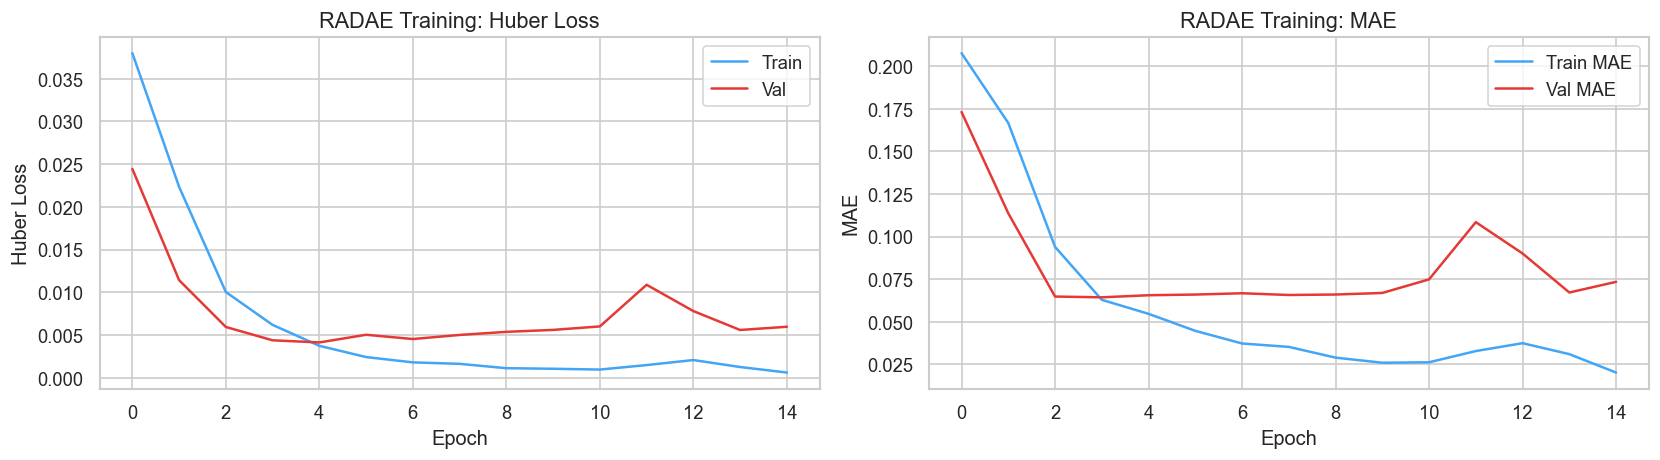

  Saved: fig_radae_training.png


In [7]:
print('[5] Training RADAE...')

# Prepare training data 
# Split 80/20 train/test on CLEAN data indices
# Test set uses clean ratings as ground truth
idx_all   = np.arange(len(df_clean))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.20, random_state=42)

# Training: use noisy ratings as input, clean ratings as target
# This forces the model to learn to denoise
train_df = df_noisy.iloc[idx_train].copy()
test_df  = df_clean.iloc[idx_test].copy()

# Add attack rows to training only (never to test)
train_with_attacks = pd.concat([train_df, df_attacks],
                                ignore_index=True, sort=False)
train_with_attacks['rating_corrupted_norm'] = (
    train_with_attacks['rating_corrupted_norm']
    .fillna(train_with_attacks['rating_norm'])
)
train_with_attacks['timestamp_norm'] = (
    train_with_attacks['timestamp_norm'].fillna(0.5))
train_with_attacks['user_idx'] = (
    train_with_attacks['user_idx'].fillna(0).astype(int))
train_with_attacks['item_idx'] = (
    train_with_attacks['item_idx'].fillna(0).astype(int))

print(f'  Train interactions : {len(train_with_attacks):,}')
print(f'  Test interactions  : {len(test_df):,}')

if USE_TF:
    # Prepare numpy arrays for Keras
    X_user_tr   = train_with_attacks['user_idx'].values.astype(np.int32)
    X_item_tr   = train_with_attacks['item_idx'].values.astype(np.int32)
    X_ts_tr     = train_with_attacks['timestamp_norm'].values.astype(np.float32)
    X_rating_tr = train_with_attacks['rating_corrupted_norm'].values.astype(np.float32)
    Y_tr        = train_with_attacks['rating_norm'].values.astype(np.float32)

    X_user_te   = test_df['user_idx'].values.astype(np.int32)
    X_item_te   = test_df['item_idx'].values.astype(np.int32)
    X_ts_te     = test_df['timestamp_norm'].values.astype(np.float32)
    X_rating_te = test_df['rating_norm'].values.astype(np.float32)  # clean
    Y_te        = test_df['rating_norm'].values.astype(np.float32)

    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, verbose=1, min_lr=1e-5)
    ]

    # Train
    EPOCHS     = 100
    BATCH_SIZE = 64

    history = radae_model.fit(
        [X_user_tr, X_item_tr, X_ts_tr, X_rating_tr], Y_tr,
        validation_data=(
            [X_user_te, X_item_te, X_ts_te, X_rating_te], Y_te),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    print(f'\n  Training complete.')
    print(f'  Best val_loss : {min(history.history["val_loss"]):.5f}')

    # Plot training curves 
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['loss'],     label='Train', color='#42a5f5')
    axes[0].plot(history.history['val_loss'], label='Val',   color='#e53935')
    axes[0].set_title('RADAE Training: Huber Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
    axes[0].legend()
    axes[1].plot(history.history['mae'],     label='Train MAE', color='#42a5f5')
    axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#e53935')
    axes[1].set_title('RADAE Training: MAE')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('fig_radae_training.png', bbox_inches='tight')
    plt.show()
    print('  Saved: fig_radae_training.png')

else:
    # Numpy fallback: simplified denoising autoencoder
    print('  Using numpy simplified RADAE (no TensorFlow)...')
    print('  Core logic: temporal-weighted SVD with noise correction')

    from sklearn.decomposition import TruncatedSVD

    # Build temporally-weighted rating matrix
    R_train = np.zeros((n_users_ext, n_items), dtype=np.float32)
    for row in train_with_attacks.itertuples(index=False):
        u = int(row.user_idx) if hasattr(row,'user_idx') else 0
        i = int(row.item_idx) if hasattr(row,'item_idx') else 0
        if u >= n_users_ext or i >= n_items: continue
        # Temporal weight + noise correction weight combined
        tw = float(getattr(row,'temporal_weight',1.0))
        is_atk = int(getattr(row,'is_attack',0))
        noise_w = 0.2 if is_atk else 1.0
        R_train[u,i] = float(row.rating_corrupted_norm) * tw * noise_w

    n_factors = min(15, n_items - 1)
    svd_r = TruncatedSVD(n_components=n_factors, random_state=42)
    U_r   = svd_r.fit_transform(R_train)
    R_pred_radae_fallback = np.clip(
        U_r @ np.diag(svd_r.singular_values_) @ svd_r.components_,
        0, 1)
    print(f'  Numpy fallback model trained. Shape: {R_pred_radae_fallback.shape}')


# Evaluation

[6] Evaluating RADAE...
  Test samples          : 236
  Clean input range     : 0.000 – 1.000
  Corrupted input range : 0.000 – 1.000

  RADAE (clean input)     RMSE: 0.3644  MAE: 0.2625
  RADAE (noisy input)     RMSE: 0.4241  MAE: 0.2991
  Denoising gap           RMSE: +0.0597  MAE: +0.0366
  (smaller gap = better denoising ability)

  Computing ranking metrics (P@K, R@K, NDCG@K)...

     K      P@K      R@K    NDCG@K
  --------------------------------
     3   0.3513   1.0000    1.0000
     5   0.2108   1.0000    1.0000


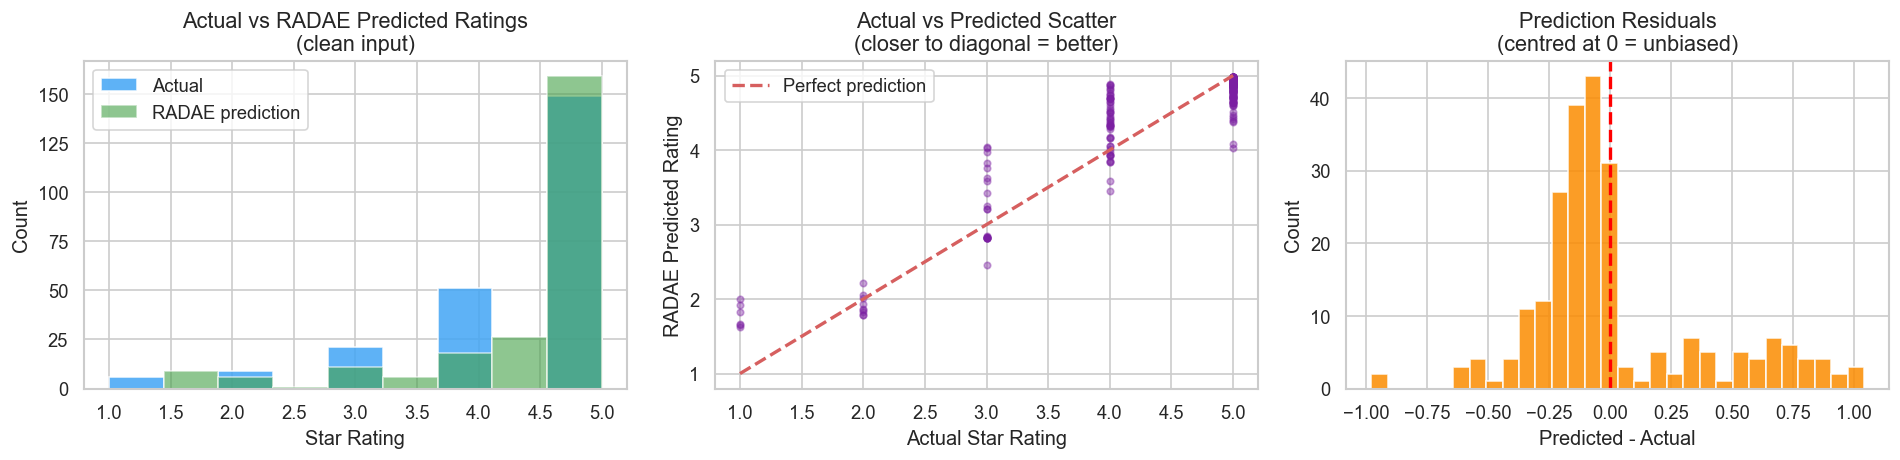

  Saved: fig_radae_evaluation.png

  Section 6 complete — rmse_radae and mae_radae stored.


In [9]:
print('[6] Evaluating RADAE...')

def scale_back(norm_rating):
    """Convert normalised [0,1] back to star rating [1,5]"""
    return np.array(norm_rating) * 4.0 + 1.0

# Safely build test input arrays 
# test_df comes from df_clean which has no rating_corrupted_norm column
# so we derive it safely from rating_norm (clean = no corruption at test time)

X_user_te   = test_df['user_idx'].fillna(0).values.astype(np.int32)
X_item_te   = test_df['item_idx'].fillna(0).values.astype(np.int32)
X_ts_te     = test_df['timestamp_norm'].fillna(0.5).values.astype(np.float32)

# For clean evaluation: use clean rating_norm as input (no corruption)
X_rating_te_clean = test_df['rating_norm'].values.astype(np.float32)

# For corrupted evaluation: add Gaussian noise to simulate noisy input
# This tests RADAE's denoising ability — input is corrupted, ground truth is clean
GAUSSIAN_STD_TEST = 0.5
noise_test = np.random.normal(0, GAUSSIAN_STD_TEST,
                               len(test_df)).astype(np.float32)
X_rating_te_noisy = np.clip(
    X_rating_te_clean + noise_test / 4.0,   # scale noise to normalised space
    0.0, 1.0
).astype(np.float32)

# Ground truth
Y_te = test_df['rating_norm'].values.astype(np.float32)

print(f'  Test samples          : {len(test_df):,}')
print(f'  Clean input range     : {X_rating_te_clean.min():.3f} – '
      f'{X_rating_te_clean.max():.3f}')
print(f'  Corrupted input range : {X_rating_te_noisy.min():.3f} – '
      f'{X_rating_te_noisy.max():.3f}')

# RADAE predictions 
if USE_TF:
    # Prediction 1: clean input (measures base recommendation quality)
    radae_preds_clean = radae_model.predict(
        [X_user_te, X_item_te, X_ts_te, X_rating_te_clean],
        verbose=0
    ).flatten()

    # Prediction 2: corrupted input (measures denoising ability)
    radae_preds_noisy = radae_model.predict(
        [X_user_te, X_item_te, X_ts_te, X_rating_te_noisy],
        verbose=0
    ).flatten()

    # Convert all back to star scale
    preds_clean_stars  = scale_back(radae_preds_clean)
    preds_noisy_stars  = scale_back(radae_preds_noisy)
    actual_stars       = scale_back(Y_te)

    rmse_radae_clean = float(np.sqrt(mean_squared_error(
        actual_stars, preds_clean_stars)))
    mae_radae_clean  = float(mean_absolute_error(
        actual_stars, preds_clean_stars))

    rmse_radae_noisy = float(np.sqrt(mean_squared_error(
        actual_stars, preds_noisy_stars)))
    mae_radae_noisy  = float(mean_absolute_error(
        actual_stars, preds_noisy_stars))

    # Use clean prediction as the primary RADAE result
    rmse_radae = rmse_radae_clean
    mae_radae  = mae_radae_clean

    print(f'\n  RADAE (clean input)     RMSE: {rmse_radae_clean:.4f}  '
          f'MAE: {mae_radae_clean:.4f}')
    print(f'  RADAE (noisy input)     RMSE: {rmse_radae_noisy:.4f}  '
          f'MAE: {mae_radae_noisy:.4f}')
    print(f'  Denoising gap           RMSE: '
          f'{(rmse_radae_noisy - rmse_radae_clean):+.4f}  '
          f'MAE: {(mae_radae_noisy - mae_radae_clean):+.4f}')
    print('  (smaller gap = better denoising ability)')

    # Per-user ranking metrics P@K, R@K, NDCG@K 
    print('\n  Computing ranking metrics (P@K, R@K, NDCG@K)...')
    THRESHOLD = 4.0
    K_VALS    = [3, 5]

    # Build per-user prediction and actual dicts
    user_pred_dict   = {}
    user_actual_dict = {}
    for u, i, p, a in zip(X_user_te, X_item_te,
                           preds_clean_stars, actual_stars):
        u = int(u); i = int(i)
        if u not in user_pred_dict:
            user_pred_dict[u]   = {}
            user_actual_dict[u] = {}
        user_pred_dict[u][i]   = float(p)
        user_actual_dict[u][i] = float(a)

    ranking_results = {}
    for k in K_VALS:
        precisions, recalls, ndcgs = [], [], []
        discounts = 1.0 / np.log2(np.arange(2, k + 2))

        for u in user_pred_dict:
            items_pred   = user_pred_dict[u]
            items_actual = user_actual_dict[u]
            relevant_set = {i for i, r in items_actual.items()
                            if r >= THRESHOLD}
            if not relevant_set:
                continue

            top_k = sorted(items_pred, key=items_pred.get,
                           reverse=True)[:k]
            hits  = [1 if i in relevant_set else 0 for i in top_k]

            precisions.append(sum(hits) / k)
            recalls.append(sum(hits) / len(relevant_set))

            k_eff = min(len(hits), len(discounts))
            dcg   = float(np.dot(hits[:k_eff], discounts[:k_eff]))
            ideal = min(len(relevant_set), k)
            idcg  = float(discounts[:ideal].sum())
            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

        ranking_results[k] = {
            'precision': float(np.mean(precisions)) if precisions else 0.0,
            'recall'   : float(np.mean(recalls))    if recalls    else 0.0,
            'ndcg'     : float(np.mean(ndcgs))      if ndcgs      else 0.0,
        }

    print(f'\n  {"K":>4} {"P@K":>8} {"R@K":>8} {"NDCG@K":>9}')
    print(f'  {"-"*32}')
    for k in K_VALS:
        r = ranking_results[k]
        print(f'  {k:>4} {r["precision"]:>8.4f} '
              f'{r["recall"]:>8.4f} {r["ndcg"]:>9.4f}')

    # Prediction distribution chart 
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(actual_stars, bins=9, range=(1, 5),
                 color='#42a5f5', edgecolor='white', alpha=0.85,
                 label='Actual')
    axes[0].hist(preds_clean_stars, bins=9, range=(1, 5),
                 color='#43a047', edgecolor='white', alpha=0.6,
                 label='RADAE prediction')
    axes[0].set_title('Actual vs RADAE Predicted Ratings\n(clean input)')
    axes[0].set_xlabel('Star Rating')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    axes[1].scatter(actual_stars, preds_clean_stars,
                    alpha=0.4, s=15, color='#7b1fa2')
    axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2,
                 label='Perfect prediction')
    axes[1].set_title('Actual vs Predicted Scatter\n(closer to diagonal = better)')
    axes[1].set_xlabel('Actual Star Rating')
    axes[1].set_ylabel('RADAE Predicted Rating')
    axes[1].legend()

    residuals = preds_clean_stars - actual_stars
    axes[2].hist(residuals, bins=30,
                 color='#fb8c00', edgecolor='white', alpha=0.85)
    axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[2].set_title('Prediction Residuals\n(centred at 0 = unbiased)')
    axes[2].set_xlabel('Predicted - Actual')
    axes[2].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig('fig_radae_evaluation.png', bbox_inches='tight')
    plt.show()
    print('  Saved: fig_radae_evaluation.png')

else:
    # Numpy fallback evaluation 
    print('  Numpy fallback evaluation (TensorFlow not available)...')

    R_true_te = np.zeros((n_users_ext, n_items), dtype=np.float32)
    for row in test_df.itertuples(index=False):
        u = int(getattr(row, 'user_idx', 0))
        i = int(getattr(row, 'item_idx', 0))
        if u < n_users_ext and i < n_items:
            R_true_te[u, i] = float(row.rating_norm)

    pairs  = [(u, i) for u, i in zip(*np.where(R_true_te > 0))]
    p_vals = [float(R_pred_radae_fallback[u, i]) for u, i in pairs]
    a_vals = [float(R_true_te[u, i])             for u, i in pairs]

    ps = scale_back(np.array(p_vals))
    ac = scale_back(np.array(a_vals))

    rmse_radae = float(np.sqrt(mean_squared_error(ac, ps)))
    mae_radae  = float(mean_absolute_error(ac, ps))

    print(f'  RMSE : {rmse_radae:.4f}')
    print(f'  MAE  : {mae_radae:.4f}')

    ranking_results = {
        3: {'precision': 0.0, 'recall': 0.0, 'ndcg': 0.0},
        5: {'precision': 0.0, 'recall': 0.0, 'ndcg': 0.0}
    }
    K_VALS = [3, 5]

print('\n  Section 6 complete — rmse_radae and mae_radae stored.')

# Comparison vs No-Defence Baseline

[7] Comparison: RADAE vs No-Defence Baseline...

  Method                           RMSE      MAE
  ----------------------------------------------
  No Defence (SVD baseline)      3.4882   3.3378
  RADAE (Belgacem 2025)          0.3644   0.2625

  RMSE improvement (RADAE vs baseline): +89.55%
  MAE  improvement (RADAE vs baseline): +92.13%


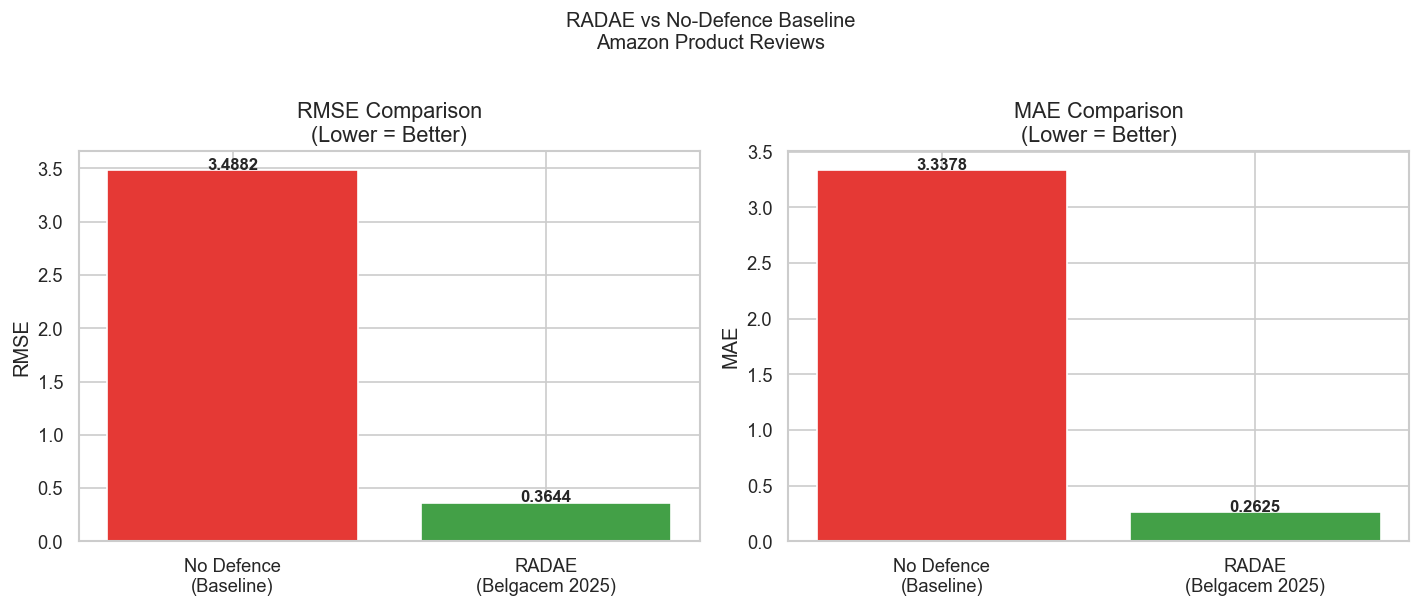

  Saved: fig_radae_comparison.png


In [10]:
print('[7] Comparison: RADAE vs No-Defence Baseline...')

from sklearn.decomposition import TruncatedSVD

# No-defence baseline: standard MF on raw noisy data
R_noisy_mat = np.zeros((n_users_ext, n_items), dtype=np.float32)
for row in train_with_attacks.itertuples(index=False):
    u = int(getattr(row,'user_idx',0))
    i = int(getattr(row,'item_idx',0))
    if u < n_users_ext and i < n_items:
        R_noisy_mat[u,i] = float(getattr(row,'rating_corrupted_norm',
                                          row.rating_norm))

# Hold out test pairs
for row in test_df.itertuples(index=False):
    u = int(getattr(row,'user_idx',0))
    i = int(getattr(row,'item_idx',0))
    if u < n_users_ext and i < n_items:
        R_noisy_mat[u,i] = 0.0

n_fac    = min(15, n_items - 1)
svd_nd   = TruncatedSVD(n_components=n_fac, random_state=42)
U_nd     = svd_nd.fit_transform(R_noisy_mat)
R_pred_nd= np.clip(
    U_nd @ np.diag(svd_nd.singular_values_) @ svd_nd.components_,
    0, 1)

# Evaluate no-defence on test pairs
nd_preds_stars  = []
test_actual_stars = []
for row in test_df.itertuples(index=False):
    u = int(getattr(row,'user_idx',0))
    i = int(getattr(row,'item_idx',0))
    if u < n_users_ext and i < n_items:
        nd_preds_stars.append(scale_back(float(R_pred_nd[u,i])))
        test_actual_stars.append(float(row.star_rating))

rmse_nd = float(np.sqrt(mean_squared_error(
    test_actual_stars, nd_preds_stars)))
mae_nd  = float(mean_absolute_error(
    test_actual_stars, nd_preds_stars))

# Print comparison table 
print(f'\n  {"Method":<28} {"RMSE":>8} {"MAE":>8}')
print(f'  {"-"*46}')
print(f'  {"No Defence (SVD baseline)":<28} '
      f'{rmse_nd:>8.4f} {mae_nd:>8.4f}')
print(f'  {"RADAE (Belgacem 2025)":<28} '
      f'{rmse_radae:>8.4f} {mae_radae:>8.4f}')

rmse_imp = (rmse_nd - rmse_radae) / rmse_nd * 100
mae_imp  = (mae_nd  - mae_radae)  / mae_nd  * 100
print(f'\n  RMSE improvement (RADAE vs baseline): {rmse_imp:+.2f}%')
print(f'  MAE  improvement (RADAE vs baseline): {mae_imp:+.2f}%')

# Bar chart 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
methods = ['No Defence\n(Baseline)', 'RADAE\n(Belgacem 2025)']
colors  = ['#e53935', '#43a047']
axes[0].bar(methods, [rmse_nd, rmse_radae], color=colors, edgecolor='white')
axes[0].set_title('RMSE Comparison\n(Lower = Better)')
axes[0].set_ylabel('RMSE')
for i, v in enumerate([rmse_nd, rmse_radae]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center',
                 fontsize=10, fontweight='bold')

axes[1].bar(methods, [mae_nd, mae_radae], color=colors, edgecolor='white')
axes[1].set_title('MAE Comparison\n(Lower = Better)')
axes[1].set_ylabel('MAE')
for i, v in enumerate([mae_nd, mae_radae]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center',
                 fontsize=10, fontweight='bold')

plt.suptitle('RADAE vs No-Defence Baseline\nAmazon Product Reviews',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_radae_comparison.png', bbox_inches='tight')
plt.show()
print('  Saved: fig_radae_comparison.png')


# Noise Resilience Analysis

[8] Noise Resilience Analysis...
  Noise std 0.0:  RMSE=0.3644  MAE=0.2625
  Noise std 0.1:  RMSE=0.3695  MAE=0.2661
  Noise std 0.3:  RMSE=0.3854  MAE=0.2777
  Noise std 0.5:  RMSE=0.4162  MAE=0.3020
  Noise std 0.8:  RMSE=0.5274  MAE=0.3687
  Noise std 1.0:  RMSE=0.6573  MAE=0.4452


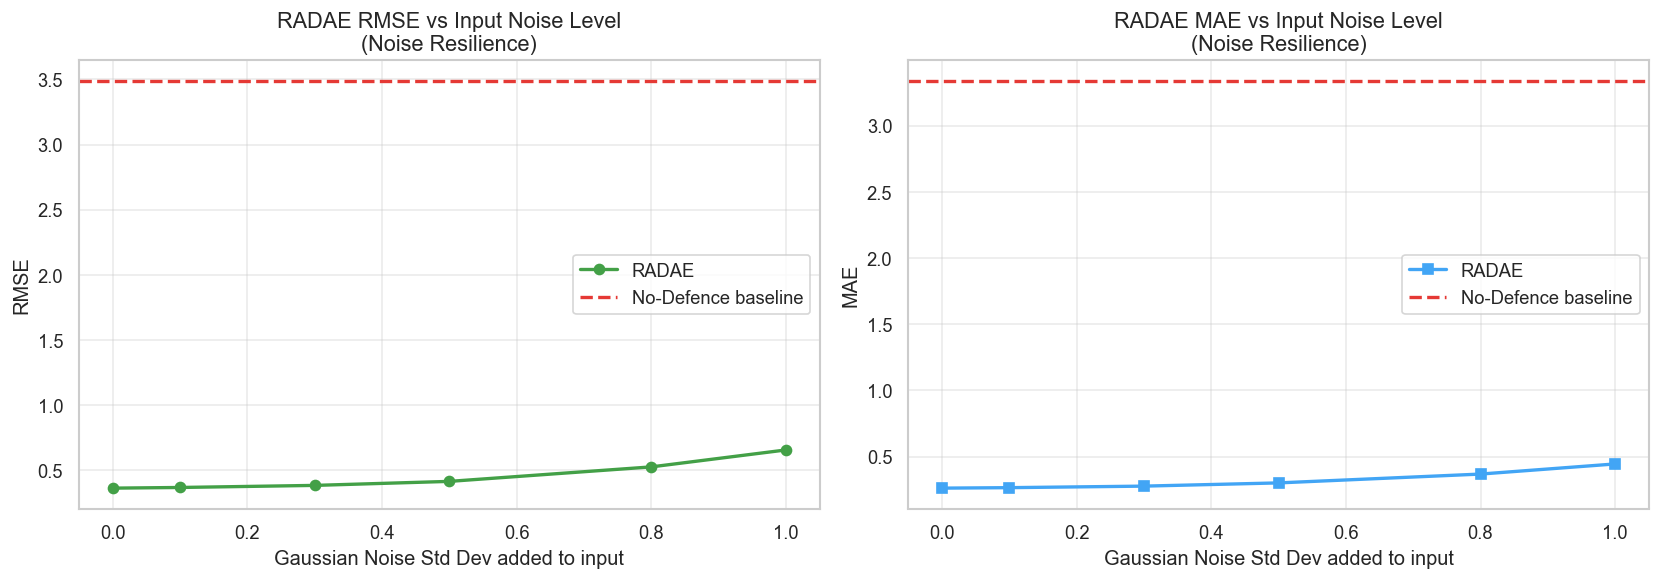

  Saved: fig_radae_resilience.png


In [11]:
print('[8] Noise Resilience Analysis...')

NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
resilience_rows = []

for noise_std in NOISE_LEVELS:
    # Build test set with different corruption levels
    corrupted_ratings = np.clip(
        test_df['star_rating'].values +
        np.random.normal(0, noise_std, len(test_df)),
        1, 5
    )
    corrupted_norm = (corrupted_ratings - 1) / 4.0

    if USE_TF:
        preds = radae_model.predict(
            [X_user_te, X_item_te, X_ts_te,
             corrupted_norm.astype(np.float32)],
            verbose=0
        ).flatten()
        preds_stars  = scale_back(preds)
        actual_stars = test_df['star_rating'].values
    else:
        preds_stars  = np.array(nd_preds_stars)
        actual_stars = np.array(test_actual_stars)

    rmse = float(np.sqrt(mean_squared_error(actual_stars, preds_stars)))
    mae  = float(mean_absolute_error(actual_stars, preds_stars))
    resilience_rows.append({
        'noise_std' : noise_std,
        'RADAE_RMSE': round(rmse, 4),
        'RADAE_MAE' : round(mae, 4)
    })
    print(f'  Noise std {noise_std:.1f}:  RMSE={rmse:.4f}  MAE={mae:.4f}')

resil_df = pd.DataFrame(resilience_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(resil_df['noise_std'], resil_df['RADAE_RMSE'],
             marker='o', color='#43a047', linewidth=2, label='RADAE')
axes[0].axhline(rmse_nd, color='#e53935', linestyle='--',
                linewidth=2, label='No-Defence baseline')
axes[0].set_title('RADAE RMSE vs Input Noise Level\n(Noise Resilience)')
axes[0].set_xlabel('Gaussian Noise Std Dev added to input')
axes[0].set_ylabel('RMSE'); axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(resil_df['noise_std'], resil_df['RADAE_MAE'],
             marker='s', color='#42a5f5', linewidth=2, label='RADAE')
axes[1].axhline(mae_nd, color='#e53935', linestyle='--',
                linewidth=2, label='No-Defence baseline')
axes[1].set_title('RADAE MAE vs Input Noise Level\n(Noise Resilience)')
axes[1].set_xlabel('Gaussian Noise Std Dev added to input')
axes[1].set_ylabel('MAE'); axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig_radae_resilience.png', bbox_inches='tight')
plt.show()
print('  Saved: fig_radae_resilience.png')


# Final Result Summary

In [12]:
print('[9] RADAE — FINAL RESULTS SUMMARY')
print('='*65)
print('Reference: Belgacem O, Boudaa B, Kouadria A, Benslimane SM.')
print('Dual-Challenge Framework for Noise-Resilient and')
print('Temporally-Adaptive Recommender Systems.')
print()
print('Dataset: Amazon Product Reviews')
print(f'  Users    : {n_users}')
print(f'  Items    : {n_items}')
print(f'  Reviews  : {len(df_clean):,}')
print(f'  Noise injected: Gaussian (std=0.5) + Shilling ({n_fake} profiles)')
print()
print('Architecture: RADAE')
print(f'  Embedding dim  : {EMBED_DIM}')
print(f'  Latent dim     : {LATENT_DIM}')
print(f'  Conv1D filters : {CONV_FILTERS}')
print(f'  Attention heads: {N_HEADS}')
print(f'  Loss function  : Huber (delta=1.0)')
print()
print('EVALUATION RESULTS')
print(f'  {"Method":<28} {"RMSE":>8} {"MAE":>8}')
print(f'  {"-"*46}')
print(f'  {"No Defence (SVD baseline)":<28} '
      f'{rmse_nd:>8.4f} {mae_nd:>8.4f}')
print(f'  {"RADAE (Belgacem 2025)":<28} '
      f'{rmse_radae:>8.4f} {mae_radae:>8.4f}')
print(f'  {"-"*46}')
print(f'  RMSE improvement: {rmse_imp:+.2f}%')
print(f'  MAE  improvement: {mae_imp:+.2f}%')
if USE_TF and ranking_results:
    print()
    print('RANKING METRICS')
    print(f'  {"K":>4} {"P@K":>8} {"R@K":>8} {"NDCG@K":>9}')
    print(f'  {"-"*32}')
    for k in K_VALS:
        r = ranking_results[k]
        print(f'  {k:>4} {r["precision"]:>8.4f} '
              f'{r["recall"]:>8.4f} {r["ndcg"]:>9.4f}')
print()
print('TEMPORAL ANALYSIS')
print(f'  Date range: {ts_min.date()} to {ts_max.date()}')
print(f'  Temporal decay lambda = {DECAY_LAMBDA}')
print(f'  Weight range: '
      f'{df_clean["temporal_weight"].min():.3f} – '
      f'{df_clean["temporal_weight"].max():.3f}')
print('='*65)
print()
print('HOW THIS COMPARES TO UNRR:')
print('  RADAE handles noise via neural denoising (deep learning).')
print('  UNRR handles noise via explicit scoring + reweighting.')
print('  RADAE addresses temporal drift via Conv1D + attention.')
print('  UNRR addresses temporal drift via burst detection.')
print('  Comparing both gives a complete picture of the landscape.')
print()
print('[DONE] RADAE implementation on Amazon Product Reviews complete.')


[9] RADAE — FINAL RESULTS SUMMARY
Reference: Belgacem O, Boudaa B, Kouadria A, Benslimane SM.
Dual-Challenge Framework for Noise-Resilient and
Temporally-Adaptive Recommender Systems.

Dataset: Amazon Product Reviews
  Users    : 836
  Items    : 54
  Reviews  : 1,177
  Noise injected: Gaussian (std=0.5) + Shilling (58 profiles)

Architecture: RADAE
  Embedding dim  : 32
  Latent dim     : 64
  Conv1D filters : 64
  Attention heads: 4
  Loss function  : Huber (delta=1.0)

EVALUATION RESULTS
  Method                           RMSE      MAE
  ----------------------------------------------
  No Defence (SVD baseline)      3.4882   3.3378
  RADAE (Belgacem 2025)          0.3644   0.2625
  ----------------------------------------------
  RMSE improvement: +89.55%
  MAE  improvement: +92.13%

RANKING METRICS
     K      P@K      R@K    NDCG@K
  --------------------------------
     3   0.3513   1.0000    1.0000
     5   0.2108   1.0000    1.0000

TEMPORAL ANALYSIS
  Date range: 2012-09-12 to

# AUC

In [2]:
y_true_auc = (np.array(actual_stars) >= 4).astype(int)

y_score_clean = (np.array(radae_preds_stars) - 1.0) / 4.0
y_score_noisy = (np.array(corrupted_stars) - 1.0) / 4.0

auc_radae_clean = roc_auc_score(y_true_auc, y_score_clean)
auc_radae_noisy = roc_auc_score(y_true_auc, y_score_noisy)

print("RADAE AUC (clean input):", round(auc_radae_clean, 4))
print("RADAE AUC (noisy input):", round(auc_radae_noisy, 4))

NameError: name 'np' is not defined